## Objective

The objective of this notebook is to create, train and evaluate regression models for the demand forecasting task.

In this phase, the main goals are:

* Train regression models to predict `quantity_sold`.
* Use `quantity_sold` as the target variable.
* Compare the model results with the previous baseline models.
* Keep the temporal split, using the oldest data for training and the most recent data for testing.
* Avoid data leakage by using only features that would be available before the prediction date.

In [1]:
import os 
import sys
from pathlib import Path
ROOT = Path("..").resolve()
os.chdir(ROOT)
sys.path.append(str(ROOT))
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from src.evaluation import evaluate_forecast
from src.importance import get_feature_importance
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import joblib

DATA_PATH = Path("data/processed/modeling_dataset.csv")
df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
print("columns:", list(df.columns))
print(f"Date range: {df['sale_date'].min()} to {df['sale_date'].max()}")
df.head()

shape: (6000, 16)
columns: ['product_name', 'sale_date', 'quantity_sold', 'unit_price_brl', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'quantity_1d', 'quantity_7d', 'quantity_14d', 'rolling_1d', 'rolling_7d', 'rolling_14d', 'weather_condition']
Date range: 2025-01-15 to 2026-05-29


,product_name,sale_date,quantity_sold,unit_price_brl,day_of_week,day_of_month,month,week_of_year,is_weekend,quantity_1d,quantity_7d,quantity_14d,rolling_1d,rolling_7d,rolling_14d,weather_condition
0,Bag Delivery 45L,2025-01-15,5.0,179.1025,2,15,1,3,0,7.0,6.0,5.0,7.0,4.428571,4.071429,Ensolarado
1,Bag Delivery 45L,2025-01-16,4.0,179.2300,3,16,1,3,0,5.0,3.0,2.0,5.0,4.285714,4.071429,Ensolarado
2,Bag Delivery 45L,2025-01-17,4.0,179.7700,4,17,1,3,0,4.0,2.0,1.0,4.0,4.428571,4.214286,Chuva Leve
3,Bag Delivery 45L,2025-01-18,3.0,175.6100,5,18,1,3,1,4.0,4.0,3.0,4.0,4.714286,4.428571,Ensolarado
4,Bag Delivery 45L,2025-01-19,0.0,175.6100,6,19,1,3,1,3.0,5.0,8.0,3.0,4.571429,4.428571,Nublado


## Defining Target and Features

In [2]:
target = "quantity_sold"
numeric_features = [
    "unit_price_brl",
    "day_of_week",
    "day_of_month",
    "month",
    "week_of_year",
    "is_weekend",
    "quantity_1d",
    "quantity_7d",
    "quantity_14d",
    "rolling_1d",
    "rolling_7d",
    "rolling_14d",
]
categorical_features = ["product_name", "weather_condition"]

## Creating the Temporal Train/Test Split
The dataset will be splited into `80% with the oldest data (train)` and `20% with the newest data (test)`, given that i will make the temporal split and removing the `data leakage` column.

In [3]:
df["sale_date"] = pd.to_datetime(df["sale_date"])

unique_dates = df["sale_date"].sort_values().unique()

split = int(len(unique_dates) * 0.8)

train_period = unique_dates[:split]
test_period = unique_dates[split:]

print(f"Train period: {train_period.min()} to {train_period.max()}")
print(f"Test period: {test_period.min()} to {test_period.max()}") 

train = df[df["sale_date"].isin(train_period)].copy()
test = df[df["sale_date"].isin(test_period)].copy()


Train period: 2025-01-15 00:00:00 to 2026-02-18 00:00:00
Test period: 2026-02-19 00:00:00 to 2026-05-29 00:00:00


## Separating  the the X (Features) and y (Target) from the Splits

In [4]:
X_train = train.loc[:, numeric_features + categorical_features]
y_train = train[target]

X_test = test.loc[:, numeric_features + categorical_features]
y_test = test[target].to_numpy()


## Building the Preprocessor Pipeline

In [5]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False), categorical_features)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

## Training and Evaluating the Random Forest Model

In [6]:
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_pipe = Pipeline([('preprocess', preprocess),
                    ('model', rf)
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

rf_results = evaluate_forecast(y_test, y_pred_rf)


print(f"MAE: {rf_results['MAE']:.2f}")
print(f"RMSE: {rf_results['RMSE']:.2f}")
print(f"MAPE: {rf_results['MAPE']:.2f}%")


MAE: 1.30
RMSE: 1.82
MAPE: 60.31%


## Training and Evaluating the XGBoost Model

In [7]:
xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", xgb)
])

xgb_pipe.fit(X_train, y_train)

y_pred_xgb = xgb_pipe.predict(X_test)

# Demand cannot be negative
y_pred_xgb = np.clip(y_pred_xgb, 0, None)

xgb_results = evaluate_forecast(y_test, y_pred_xgb)

print(f"MAE: {xgb_results['MAE']:.2f}")
print(f"RMSE: {xgb_results['RMSE']:.2f}")
print(f"MAPE: {xgb_results['MAPE']:.2f}%")

MAE: 1.27
RMSE: 1.83
MAPE: 59.56%


## Comparing Model Results

In [8]:
comparison_df = pd.DataFrame([
    {
    "Model": "Random Forest",
    "MAE": rf_results['MAE'],
    "RMSE": rf_results['RMSE'],
    "MAPE":  rf_results['MAPE']
    },
    {
    "Model": "XGBoost",
    "MAE": xgb_results['MAE'],
    "RMSE": xgb_results['RMSE'],
    "MAPE":  xgb_results['MAPE']
    }
]).round(2)

comparison_df

,Model,MAE,RMSE,MAPE
0,Random Forest,1.30,1.82,60.31
1,XGBoost,1.27,1.83,59.56


## Visualizing Predictions

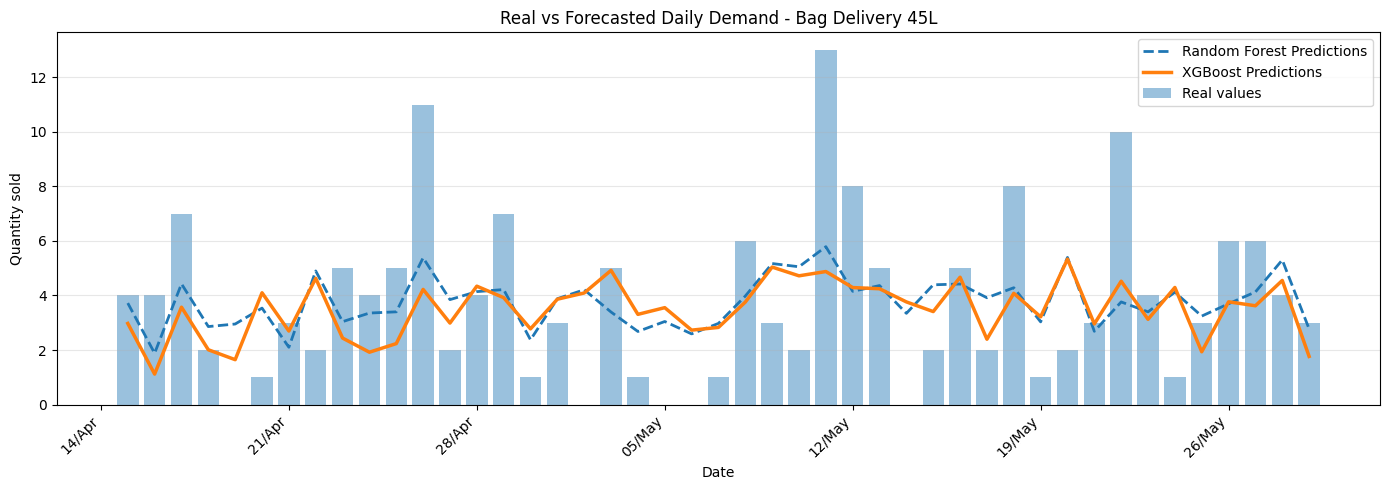

In [9]:
eval_df = test[["sale_date", "product_name", "quantity_sold"]].reset_index(drop=True).copy()
eval_df["rf_prediction"] = np.asarray(y_pred_rf).ravel()
eval_df["xgb_prediction"] = np.asarray(y_pred_xgb).ravel()
eval_df["sale_date"] = pd.to_datetime(eval_df["sale_date"])


eval_bag = (
    eval_df[eval_df["product_name"] == "Bag Delivery 45L"]
    .sort_values("sale_date")
    .tail(45)
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    eval_bag["sale_date"],
    eval_bag["quantity_sold"],
    label="Real values",
    alpha=0.45
)

ax.plot(
    eval_bag["sale_date"],
    eval_bag["rf_prediction"],
    linestyle="--",
    linewidth=2,
    label="Random Forest Predictions"
)

ax.plot(
    eval_bag["sale_date"],
    eval_bag["xgb_prediction"],
    linestyle="-",
    linewidth=2.5,
    label="XGBoost Predictions"
)

ax.set_title("Real vs Forecasted Daily Demand - Bag Delivery 45L")
ax.set_xlabel("Date")
ax.set_ylabel("Quantity sold")

ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))

ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance

In [10]:
rf_importance = get_feature_importance(rf_pipe)

rf_importance.head(5)

,feature,importance
0,rolling_14d,0.317605
1,unit_price_brl,0.174383
2,day_of_month,0.083010
3,week_of_year,0.075886
4,rolling_7d,0.064493


In [11]:
xgb_importance = get_feature_importance(xgb_pipe)
xgb_importance.head(5)

,feature,importance
0,rolling_14d,0.112770
1,product_name_Bag Delivery 45L,0.068136
2,rolling_7d,0.055682
3,product_name_Suporte Celular Moto,0.051705
4,is_weekend,0.048380


## Saving Trained Models

In [15]:
rf_path =  ROOT / "artifacts/" / "model" / "random_forest_model.pkl"
rf_path.parent.mkdir(parents=True, exist_ok=True)
xgb_path =  ROOT / "artifacts/" / "model" / "xgboost_model.pkl"
xgb_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(rf_pipe, rf_path)
joblib.dump(xgb_pipe, xgb_path)

print("Random Forest saved to: .../artifacts/models/random_forest_model.pkl")
print("XGBoost saved to: .../artifacts/models/xgboost_model.pkl")

Random Forest saved to: .../artifacts/models/random_forest_model.pkl
XGBoost saved to: .../artifacts/models/xgboost_model.pkl


## Saving Trained Results

In [14]:
trained_path = ROOT / "reports" / "model_training_results.csv"
trained_path.parent.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(trained_path, index=False, encoding="utf-8")
print("Saved the trained results dataset to:", trained_path.resolve())

Saved the trained results dataset to: C:\DEV\motostock-ai\reports\model_training_results.csv


## Model Training Summary

In this notebook, two regression models were trained to predict `quantity_sold`:

* Random Forest Regressor
* XGBoost Regressor

The dataset was split using a temporal split, with the oldest data used for training and the newest data used for testing. This is important because, in forecasting problems, the model should learn from the past and predict future values.

The ML models achieved lower average errors than the initial baseline experiment. However, the baseline was previously validated on a single product, while these models were trained globally across all products. A fully fair comparison will be refined in the model evaluation phase.

The MAPE was still high, but this happens because many products have low daily sales. In this case, small errors can generate high percentage errors. Because of that, MAE and RMSE are more useful metrics for this project.

The feature importance analysis showed that historical demand features, such as lag and rolling features, were important for the predictions. This means the models were able to learn useful patterns from past sales.

At the end of the notebook, the trained model pipelines were saved so they can be reused later in the stock recommendation phase.
